In [1]:
import pandas as pd
import statsmodels.api as sm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

In [2]:
X, y = make_regression(
    n_samples=200,
    n_features=1,
    noise=20,
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [3]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [4]:
residuals = y_test - y_pred

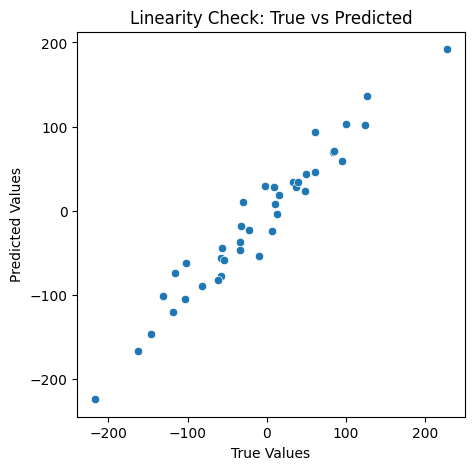

In [5]:
plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('Linearity Check: True vs Predicted')
plt.show()

La gráfica True vs Predicted muestra que los puntos siguen una tendencia lineal ascendente, lo que indica que el modelo de regresión lineal está capturando adecuadamente la relación entre las variables. A medida que los valores verdaderos aumentan, las predicciones también lo hacen de forma consistente, sin patrones de curvatura ni dispersiones irregulares que sugieran problemas. En conjunto, esta visualización confirma que el supuesto de linealidad se cumple y que el modelo está funcionando de manera coherente con la estructura lineal de los datos.

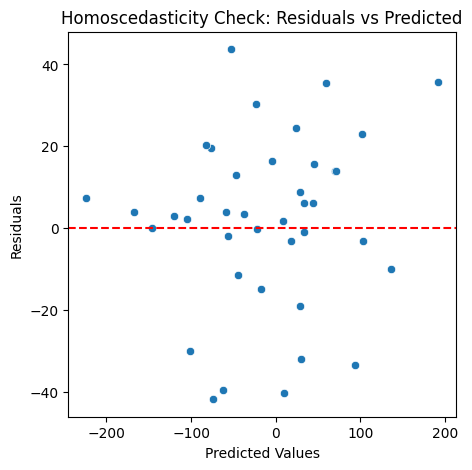

In [6]:
plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Homoscedasticity Check: Residuals vs Predicted')
plt.show()

La gráfica de Homoscedasticidad (Residuals vs Predicted) muestra que los residuos se dispersan de forma aleatoria alrededor de la línea horizontal roja (cero), sin formar patrones visibles ni un efecto “embudo” donde la varianza aumente o disminuya con los valores predichos. Esta distribución aleatoria indica que la varianza de los errores es relativamente constante, por lo que el supuesto de homocedasticidad se cumple adecuadamente en este modelo.

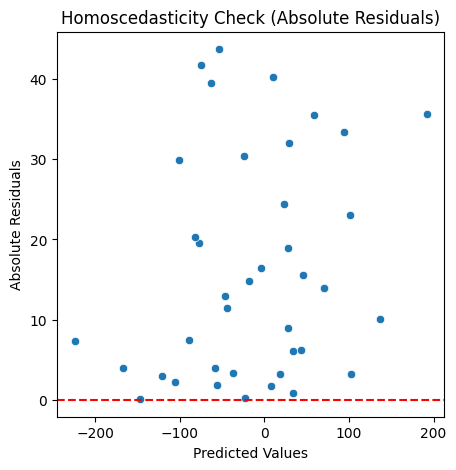

In [7]:
plt.figure(figsize=(5, 5))
sns.scatterplot(x=y_pred, y=np.abs(residuals))
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Absolute Residuals')
plt.title('Homoscedasticity Check (Absolute Residuals)')
plt.show()

La gráfica de Homoscedasticidad con residuos absolutos muestra cómo se distribuyen las magnitudes de los errores respecto a los valores predichos. En este caso, los puntos aparecen dispersos de manera aleatoria y no siguen un patrón creciente o decreciente, lo que significa que la variabilidad de los errores se mantiene relativamente constante para diferentes niveles de predicción. Esto refuerza la idea de que no hay indicios de heterocedasticidad y que el modelo cumple adecuadamente con el supuesto de homocedasticidad.

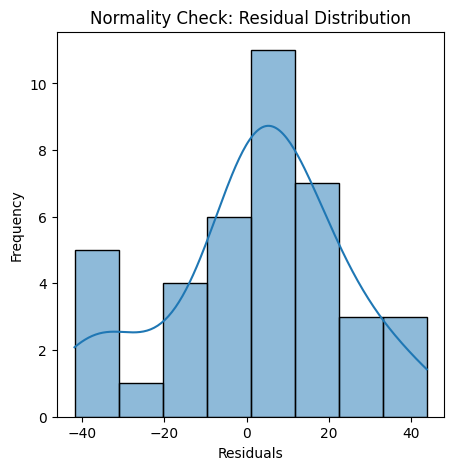

In [8]:
plt.figure(figsize=(5, 5))
sns.histplot(residuals, kde=True)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Normality Check: Residual Distribution')
plt.show()

El histograma de residuos muestra una forma aproximadamente simétrica y concentrada alrededor de cero, lo que sugiere que los errores del modelo siguen una distribución cercana a la normal. Aunque puede haber ligeras desviaciones en los extremos, la curva suavizada coincide razonablemente bien con la forma de campana esperada, por lo que se considera que el supuesto de normalidad de los residuos se cumple de manera aceptable para este modelo.

<Figure size 600x600 with 0 Axes>

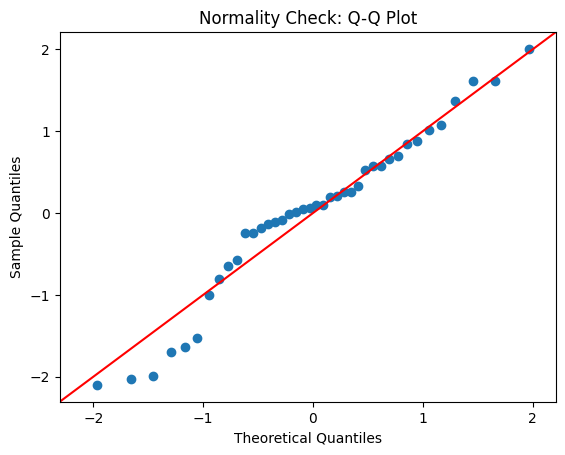

In [9]:
# Q-Q plot de los residuos
plt.figure(figsize=(6, 6))
sm.qqplot(residuals, line='45', fit=True)
plt.title('Normality Check: Q-Q Plot')
plt.show()

La gráfica Q-Q Plot muestra que los puntos siguen de manera cercana la línea diagonal roja, lo que indica que los residuos se aproximan a una distribución normal. Aunque existen pequeñas desviaciones en los extremos, la mayor parte de los puntos se alinea bien, por lo que el supuesto de normalidad se considera razonablemente cumplido.

In [10]:
# Generate dataset again
X, y = make_regression(
    n_samples=150,
    n_features=1,
    noise=30,
    random_state=0
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
# Fit model
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
residuals = y_test - y_pred

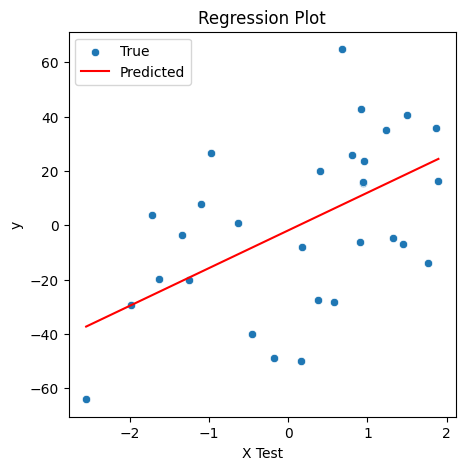

In [12]:
# Regression plot
plt.figure(figsize=(5, 5))
sns.scatterplot(x=X_test.flatten(), y=y_test, label="True")
sns.lineplot(x=X_test.flatten(), y=y_pred, label="Predicted", color='red')
plt.title("Regression Plot")
plt.xlabel("X Test")
plt.ylabel("y")
plt.show()

La gráfica muestra los valores reales como puntos y la línea roja representa las predicciones del modelo. Aunque la tendencia general es ascendente, los puntos están bastante dispersos alrededor de la línea, lo que indica que el modelo captura la relación lineal de forma limitada. En resumen, sí existe una relación lineal, pero el ajuste no es muy preciso debido a la alta variabilidad de los datos.

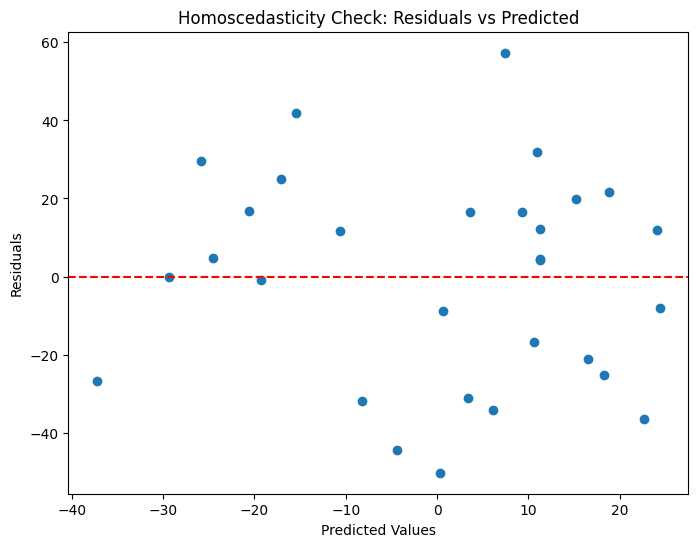

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Homoscedasticity Check: Residuals vs Predicted')
plt.show()

La gráfica muestra los residuos dispersos alrededor de la línea horizontal roja sin formar un patrón claro, sin apertura en forma de “embudo” ni acumulaciones sistemáticas. Esta dispersión aleatoria indica que la varianza de los errores se mantiene relativamente constante, por lo que el supuesto de homocedasticidad se cumple de manera razonable en este modelo.

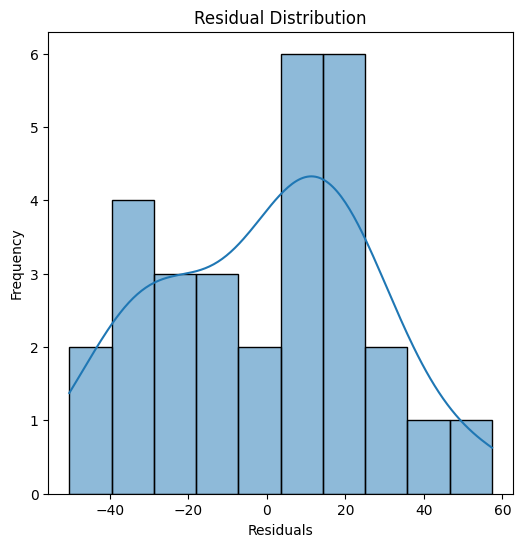

In [14]:
plt.figure(figsize=(6, 6))
sns.histplot(residuals, bins=10, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

La gráfica muestra un histograma de los residuos con una curva de densidad que ayuda a visualizar su forma. Aunque la distribución no es perfectamente simétrica, la mayoría de los residuos se concentran alrededor de valores cercanos a cero y siguen una forma aproximadamente similar a una campana. Esto sugiere que los residuos presentan una distribución moderadamente normal, suficiente para considerar que el supuesto de normalidad se cumple de manera aceptable.

<Figure size 600x600 with 0 Axes>

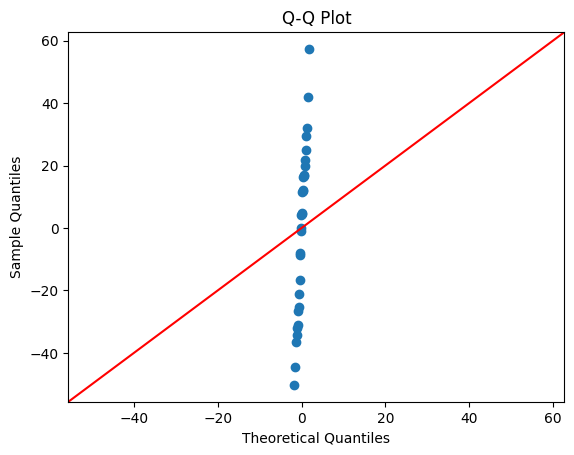

In [15]:
plt.figure(figsize=(6, 6))
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot")
plt.show()

La gráfica Q-Q Plot muestra que los puntos se desvían notablemente de la línea roja, especialmente en los extremos. Esto indica que los residuos no siguen una distribución normal, ya que deberían alinearse de forma cercana a la diagonal si la normalidad se cumpliera. En resumen, este modelo presenta una clara desviación respecto al supuesto de normalidad.